In [27]:
import pandas as pd
import numpy as np
from scipy.optimize import minimize

from matplotlib import pyplot as plt
import matplotlib.dates as mdates
from matplotlib.ticker import FuncFormatter

import code_for_project_1
from importlib import reload

reload(code_for_project_1)
get_data = code_for_project_1.get_data
save_experiment_outputs = code_for_project_1.save_experiment_outputs

In [28]:
index_return_df, market_value_df = get_data(refresh_csv=True)
returns_df, market_df = index_return_df.copy(), market_value_df.copy()

D:\python_learning_virtual_evns\.venv\Lib\site-packages\openpyxl\worksheet\_reader.py:329: UserWarning: Unknown extension is not supported and will be removed
  warn(msg)
D:\python_learning_virtual_evns\.venv\Lib\site-packages\openpyxl\worksheet\_reader.py:329: UserWarning: Unknown extension is not supported and will be removed
  warn(msg)


In [29]:
returns_df
returns_df.columns, len(returns_df), returns_df['Date'].min(), returns_df['Date'].max()

(Index(['Date', 'Russell 1000 Value', 'Russell 1000 Growth',
        'Russell 2000 Value', 'Russell 2000 Growth',
        'MSCI World Ex USA Value NR USD', 'MSCI World Ex USA Growth NR USD',
        'MSCI World Ex USA Small Value NR USD',
        'MSCI World Ex USA Small Growth NR USD', 'MSCI EM Value NR USD',
        'MSCI EM Growth NR USD', 'MSCI EM Small Value NR USD',
        'MSCI EM Small Growth NR USD', 'Bloomberg Barclays US Aggregate',
        'Bloomberg Barclays Global Aggregate x USD',
        'Bloomberg Barclays Global Inflation-Linked USD',
        'Bloomberg Barclays US Municipal Bond',
        'Bloomberg Barclays Global High Yield USD', 'Bloomberg Commodity Index',
        'ICE BofA US Dollar Deposit Offered Rate Constant Maturity (1M)'],
       dtype='str'),
 300,
 np.int64(20010131),
 np.int64(20251231))

In [30]:
market_df
market_df.columns, len(market_df), market_df['Date'].min(), market_df['Date'].max()

(Index(['Date', 'Russell 1000 Value', 'Russell 1000 Growth',
        'Russell 2000 Value', 'Russell 2000 Growth',
        'MSCI World Ex USA Value NR USD', 'MSCI World Ex USA Growth NR USD',
        'MSCI World Ex USA Small Value NR USD',
        'MSCI World Ex USA Small Growth NR USD', 'MSCI EM Value NR USD',
        'MSCI EM Growth NR USD', 'MSCI EM Small Value NR USD',
        'MSCI EM Small Growth NR USD', 'Bloomberg Barclays US Aggregate',
        'Bloomberg Barclays Global Aggregate x USD',
        'Bloomberg Barclays Global Inflation-Linked',
        'Bloomberg Barclays Municipal Bond',
        'Bloomberg Barclays Global High Yield'],
       dtype='str'),
 223,
 np.int64(20070629),
 np.int64(20251231))

### Asset

In [31]:
#first test of whether there are some missing asset
for column in returns_df.columns:
    if column not in market_df.columns:
        print(f'{column} not in market_df')

Bloomberg Barclays Global Inflation-Linked USD not in market_df
Bloomberg Barclays US Municipal Bond not in market_df
Bloomberg Barclays Global High Yield USD not in market_df
Bloomberg Commodity Index not in market_df
ICE BofA US Dollar Deposit Offered Rate Constant Maturity (1M) not in market_df


In [32]:
# use the same column name in two csv
market_df.rename(columns={
    'Bloomberg Barclays Global Inflation-Linked': 'Bloomberg Barclays Global Inflation-Linked USD',
    'Bloomberg Barclays Municipal Bond': 'Bloomberg Barclays US Municipal Bond',
    'Bloomberg Barclays Global High Yield': 'Bloomberg Barclays Global High Yield USD'}, inplace=True)

In [33]:
#second test of different assets
mkt_lack = [column for column in returns_df.columns if column not in market_df.columns]
ret_lack = [column for column in market_df.columns if column not in returns_df.columns]
print('mkt_lack:', mkt_lack)
print('ret_lack:', ret_lack)

mkt_lack: ['Bloomberg Commodity Index', 'ICE BofA US Dollar Deposit Offered Rate Constant Maturity (1M)']
ret_lack: []


In [34]:
#freeze the common asset
COMMON_ASSETS = [column for column in returns_df.columns if column in market_df.columns and column != 'Date']
print(COMMON_ASSETS, len(COMMON_ASSETS))
returns_common = returns_df[['Date'] + COMMON_ASSETS].copy()
market_common = market_df[['Date'] + COMMON_ASSETS].copy()

['Russell 1000 Value', 'Russell 1000 Growth', 'Russell 2000 Value', 'Russell 2000 Growth', 'MSCI World Ex USA Value NR USD', 'MSCI World Ex USA Growth NR USD', 'MSCI World Ex USA Small Value NR USD', 'MSCI World Ex USA Small Growth NR USD', 'MSCI EM Value NR USD', 'MSCI EM Growth NR USD', 'MSCI EM Small Value NR USD', 'MSCI EM Small Growth NR USD', 'Bloomberg Barclays US Aggregate', 'Bloomberg Barclays Global Aggregate x USD', 'Bloomberg Barclays Global Inflation-Linked USD', 'Bloomberg Barclays US Municipal Bond', 'Bloomberg Barclays Global High Yield USD'] 17


### Time Check

In [35]:
#common missing value markers
COMMON_MISSING_VALUES = [
    '', ' ', 'NA', 'N/A', 'na', 'n/a',
    'NaN', 'nan', 'NULL', 'null',
    'None', 'none', '-', '--', '.'
]

In [36]:
#1.Standardize dates' types
returns_common['Date'] = returns_common['Date'].replace(COMMON_MISSING_VALUES, np.nan)
market_common['Date'] = market_common['Date'].replace(COMMON_MISSING_VALUES, np.nan)
returns_common['Date'] = pd.to_datetime(
    returns_common['Date'].astype('string'), format='%Y%m%d', errors='coerce'
)
market_common['Date'] = pd.to_datetime(
    market_common['Date'].astype('string'), format='%Y%m%d', errors='coerce'
)

#2. sort(from past to now)
returns_common = returns_common.sort_values('Date').reset_index(drop=True)
market_common = market_common.sort_values('Date').reset_index(drop=True)

#basic check
print('returns duplicated dates:',
      returns_common['Date'].duplicated().sum())
print('market duplicated dates:',
      market_common['Date'].duplicated().sum())

print('returns Date missing/invalid after cleaning:',
      returns_common['Date'].isna().sum())
print('market Date missing/invalid after cleaning:',
      market_common['Date'].isna().sum())

returns duplicated dates: 0
market duplicated dates: 0
returns Date missing/invalid after cleaning: 0
market Date missing/invalid after cleaning: 0


In [37]:
#3. check row-by-row year-month continuity
returns_month_num = (
        returns_common['Date'].dt.year * 12 + returns_common['Date'].dt.month)
market_month_num = (
        market_common['Date'].dt.year * 12 + market_common['Date'].dt.month)

returns_month_breaks = returns_common.loc[
    returns_month_num.diff().fillna(1).ne(1), 'Date']
market_month_breaks = market_common.loc[
    market_month_num.diff().fillna(1).ne(1), 'Date']

print('returns row-by-row year-month breaks:')
print(returns_month_breaks.tolist())
print('market row-by-row year-month breaks:')
print(market_month_breaks.tolist())

#4. check whether market dates are fully covered by returns months


market_date_not_in_returns = set(market_common['Date']) - set(returns_common['Date'])
returns_date_not_in_market = set(returns_common['Date']) - set(market_common['Date'])

print('market dates missing in returns:', len(market_date_not_in_returns))
print('returns dates not in market:', len(returns_date_not_in_market))


returns row-by-row year-month breaks:
[]
market row-by-row year-month breaks:
[]
market dates missing in returns: 0
returns dates not in market: 77


### Asset Check

In [38]:
for df in [returns_common, market_common]:
    df[COMMON_ASSETS] = (
        df[COMMON_ASSETS]
        .replace(COMMON_MISSING_VALUES, np.nan)
        .apply(pd.to_numeric, errors='coerce')
    )

#check all common asset columns
returns_missing_by_asset = (
    returns_common[COMMON_ASSETS].isna().sum().sort_values(ascending=False))
market_missing_by_asset = (
    market_common[COMMON_ASSETS].isna().sum().sort_values(ascending=False))

print('returns assets with missing:')
print(returns_missing_by_asset[returns_missing_by_asset > 0])
print('market assets with missing:')
print(market_missing_by_asset[market_missing_by_asset > 0])

returns assets with missing:
Series([], dtype: int64)
market assets with missing:
Series([], dtype: int64)


In [39]:
market_non_positive = (
    (market_common[COMMON_ASSETS] <= 0).sum().sort_values(ascending=False)
)
print('market non-positive by asset:')
print(market_non_positive[market_non_positive > 0])

market non-positive by asset:
Series([], dtype: int64)


In [40]:
returns_less_than_1 = (
    (returns_common[COMMON_ASSETS] <= -1).sum().sort_values(ascending=False)
)
print(
    f"returns less than 1 by asset: {returns_less_than_1[returns_less_than_1 > 0]}")

returns less than 1 by asset: Series([], dtype: int64)


### Construct Benchmark

In [41]:
FORMATION_DATES = 6

formation_candidates = (
    market_common.loc[
        market_common['Date'].dt.month.eq(FORMATION_DATES), ['Date']]
    .assign(Year=market_common['Date'].dt.year)
    .groupby('Year', as_index=False)['Date'].max()
    .rename(columns={'Date': 'formation_dates'})
)

formation_candidates

,Year,formation_dates
0,2007,2007-06-29
1,2008,2008-06-30
2,2009,2009-06-30
3,2010,2010-06-30
4,2011,2011-06-30
5,2012,2012-06-29
6,2013,2013-06-28
7,2014,2014-06-30
8,2015,2015-06-30
9,2016,2016-06-30


In [42]:
#we need 36 months before the date we construct a portfolio at least(returns) and 12 months after because we want to keep the portfolio for a whole year.

valid_formation_dates = []
non_valid_formation_dates = []
for formation_date in formation_candidates['formation_dates']:
    previous_months = (returns_common['Date'] < formation_date).sum()
    future_months = (returns_common['Date'] > formation_date).sum()

    if previous_months >= 60 and future_months >= 12:
        valid_formation_dates.append(formation_date)

    else:
        non_valid_formation_dates.append(formation_date)

print('formation dates valid:')
print(valid_formation_dates)
print('non-valid formation dates valid:')
print(non_valid_formation_dates)



formation dates valid:
[Timestamp('2007-06-29 00:00:00'), Timestamp('2008-06-30 00:00:00'), Timestamp('2009-06-30 00:00:00'), Timestamp('2010-06-30 00:00:00'), Timestamp('2011-06-30 00:00:00'), Timestamp('2012-06-29 00:00:00'), Timestamp('2013-06-28 00:00:00'), Timestamp('2014-06-30 00:00:00'), Timestamp('2015-06-30 00:00:00'), Timestamp('2016-06-30 00:00:00'), Timestamp('2017-06-30 00:00:00'), Timestamp('2018-06-29 00:00:00'), Timestamp('2019-06-28 00:00:00'), Timestamp('2020-06-30 00:00:00'), Timestamp('2021-06-30 00:00:00'), Timestamp('2022-06-30 00:00:00'), Timestamp('2023-06-30 00:00:00'), Timestamp('2024-06-28 00:00:00')]
non-valid formation dates valid:
[Timestamp('2025-06-30 00:00:00')]


In [43]:
benchmark_rows = []

for formation_date in valid_formation_dates:
    market_row = market_common.loc[
        market_common['Date'].eq(formation_date), COMMON_ASSETS
    ].iloc[0] #series

    weights = market_row / market_row.sum()
    benchmark_rows.append({'Date': formation_date, **weights.to_dict()})

benchmarks = pd.DataFrame(benchmark_rows)
benchmarks


,Date,Russell 1000 Value,Russell 1000 Growth,Russell 2000 Value,Russell 2000 Growth,MSCI World Ex USA Value NR USD,MSCI World Ex USA Growth NR USD,MSCI World Ex USA Small Value NR USD,MSCI World Ex USA Small Growth NR USD,MSCI EM Value NR USD,MSCI EM Growth NR USD,MSCI EM Small Value NR USD,MSCI EM Small Growth NR USD,Bloomberg Barclays US Aggregate,Bloomberg Barclays Global Aggregate x USD,Bloomberg Barclays Global Inflation-Linked USD,Bloomberg Barclays US Municipal Bond,Bloomberg Barclays Global High Yield USD
0,2007-06-29,0.120977,0.120805,0.011307,0.011415,0.117192,0.117593,0.013721,0.014220,0.022105,0.022105,0.003575,0.003728,0.147376,0.224747,0.016816,0.016270,0.016049
1,2008-06-30,0.097725,0.105320,0.008113,0.008371,0.102382,0.108045,0.010282,0.011693,0.024820,0.024416,0.003175,0.003147,0.168959,0.269946,0.021939,0.017314,0.014355
2,2009-06-30,0.077594,0.081054,0.006450,0.006673,0.080207,0.079172,0.008403,0.008764,0.020946,0.020907,0.002948,0.002919,0.216049,0.329225,0.023145,0.020294,0.015251
3,2010-06-30,0.082590,0.081065,0.007042,0.007348,0.074385,0.077409,0.010097,0.010023,0.022950,0.022697,0.003332,0.003212,0.227160,0.311298,0.021587,0.019218,0.018587
4,2011-06-30,0.089483,0.087743,0.008003,0.008109,0.082261,0.082554,0.011418,0.011318,0.024271,0.025673,0.003466,0.003413,0.195538,0.309358,0.022134,0.015792,0.019467
5,2012-06-29,0.091766,0.090019,0.007524,0.007526,0.070276,0.069363,0.009504,0.009604,0.021272,0.021938,0.002851,0.002794,0.216307,0.316170,0.025358,0.017404,0.020324
6,2013-06-28,0.104404,0.095965,0.008639,0.008274,0.076097,0.076589,0.010304,0.010486,0.020120,0.021410,0.003034,0.002987,0.204002,0.294627,0.024449,0.015892,0.022721
7,2014-06-30,0.106724,0.108047,0.009371,0.009367,0.080590,0.080434,0.011927,0.011961,0.020117,0.021670,0.003225,0.003265,0.183415,0.286629,0.025326,0.014078,0.023854
8,2015-06-30,0.113777,0.115948,0.010221,0.010441,0.077142,0.077990,0.011616,0.012009,0.021636,0.021600,0.003498,0.003638,0.196213,0.258426,0.026391,0.014795,0.024658
9,2016-06-30,0.109040,0.108193,0.008579,0.008703,0.067011,0.069049,0.010898,0.011165,0.019885,0.019817,0.003190,0.003240,0.206781,0.286585,0.027555,0.015516,0.024793


In [44]:
expected_columns = ['Date'] + COMMON_ASSETS
row_sums = benchmarks[COMMON_ASSETS].sum(axis=1)

print('benchmark rows:', len(benchmarks))
print('expected rows:', len(valid_formation_dates))
print('duplicate dates:', benchmarks['Date'].duplicated().sum())
print('missing values:', benchmarks[COMMON_ASSETS].isna().sum().sum())
print('min weight:', benchmarks[COMMON_ASSETS].min().min())
print('max weight:', benchmarks[COMMON_ASSETS].max().max())
print('max |row sum - 1|:', (row_sums - 1).abs().max())

assert benchmarks.columns.tolist() == expected_columns
assert len(benchmarks) == len(valid_formation_dates)
assert benchmarks['Date'].tolist() == list(valid_formation_dates)
assert benchmarks['Date'].is_unique
assert benchmarks[COMMON_ASSETS].notna().all().all()
assert np.isfinite(benchmarks[COMMON_ASSETS].to_numpy()).all()
assert (benchmarks[COMMON_ASSETS] >= 0).all().all()
assert np.allclose(row_sums.to_numpy(), 1.0)

print('benchmark checks passed')


benchmark rows: 18
expected rows: 18
duplicate dates: 0
missing values: 0
min weight: 0.002625479736661791
max weight: 0.3292248010316403
max |row sum - 1|: 2.220446049250313e-16
benchmark checks passed


### BL Calculation

In [45]:
#covariance
COVARIANCE_WINDOW = 60
COVARIANCE_SHRINKAGE = 0.40

cov_matrices_month = {}
cov_matrices_ann = {}

for formation_date in valid_formation_dates:
    return_window = returns_common.loc[
        returns_common['Date'] < formation_date, ['Date'] + COMMON_ASSETS
    ].tail(COVARIANCE_WINDOW)

    if len(return_window) != COVARIANCE_WINDOW:
        raise ValueError(
            f'{formation_date}: expected {COVARIANCE_WINDOW} months, got {len(return_window)}'
        )

    sample_cov_month = return_window[COMMON_ASSETS].cov()
    # Simple diagonal shrinkage keeps the 17-asset covariance estimate more stable.
    diag_cov_month = pd.DataFrame(
        np.diag(np.diag(sample_cov_month.to_numpy())),
        index=COMMON_ASSETS,
        columns=COMMON_ASSETS
    )
    cov_month = (
        (1.0 - COVARIANCE_SHRINKAGE) * sample_cov_month
        + COVARIANCE_SHRINKAGE * diag_cov_month
    )
    cov_ann = 12 * cov_month

    cov_matrices_month[formation_date] = cov_month
    cov_matrices_ann[formation_date] = cov_ann

cov_matrices_ann[valid_formation_dates[0]]

,Russell 1000 Value,Russell 1000 Growth,Russell 2000 Value,Russell 2000 Growth,MSCI World Ex USA Value NR USD,MSCI World Ex USA Growth NR USD,MSCI World Ex USA Small Value NR USD,MSCI World Ex USA Small Growth NR USD,MSCI EM Value NR USD,MSCI EM Growth NR USD,MSCI EM Small Value NR USD,MSCI EM Small Growth NR USD,Bloomberg Barclays US Aggregate,Bloomberg Barclays Global Aggregate x USD,Bloomberg Barclays Global Inflation-Linked USD,Bloomberg Barclays US Municipal Bond,Bloomberg Barclays Global High Yield USD
Russell 1000 Value,0.014771,0.008218,0.009506,0.011097,0.009422,0.008099,0.007223,0.008480,0.011155,0.010741,0.010084,0.009824,-0.000530,-0.000002,-0.000531,-0.000721,0.003315
Russell 1000 Growth,0.008218,0.015706,0.008908,0.011757,0.008354,0.007144,0.006209,0.007704,0.009745,0.009929,0.009180,0.009301,-0.000746,-0.000994,-0.001434,-0.000986,0.002910
Russell 2000 Value,0.009506,0.008908,0.023626,0.016204,0.010378,0.009373,0.009214,0.010753,0.012795,0.012554,0.011203,0.011039,-0.000697,0.000294,-0.000360,-0.000779,0.003581
Russell 2000 Growth,0.011097,0.011757,0.016204,0.034037,0.012106,0.011001,0.010683,0.012872,0.015409,0.015605,0.013821,0.013954,-0.001099,-0.000567,-0.001227,-0.001277,0.004273
MSCI World Ex USA Value NR USD,0.009422,0.008354,0.010378,0.012106,0.019187,0.010011,0.009490,0.011035,0.013597,0.012869,0.012268,0.012075,-0.000508,0.000809,0.000084,-0.000659,0.003659
MSCI World Ex USA Growth NR USD,0.008099,0.007144,0.009373,0.011001,0.010011,0.015922,0.008663,0.010156,0.012003,0.011517,0.010586,0.010539,-0.000346,0.001190,0.000444,-0.000458,0.003050
MSCI World Ex USA Small Value NR USD,0.007223,0.006209,0.009214,0.010683,0.009490,0.008663,0.015603,0.010668,0.011853,0.011231,0.010882,0.010686,-0.000072,0.001454,0.000864,-0.000152,0.003189
MSCI World Ex USA Small Growth NR USD,0.008480,0.007704,0.010753,0.012872,0.011035,0.010156,0.010668,0.021214,0.013748,0.013076,0.012657,0.012480,-0.000335,0.001088,0.000387,-0.000439,0.003591
MSCI EM Value NR USD,0.011155,0.009745,0.012795,0.015409,0.013597,0.012003,0.011853,0.013748,0.034036,0.019348,0.018759,0.018274,-0.000463,0.000775,0.000131,-0.000617,0.004622
MSCI EM Growth NR USD,0.010741,0.009929,0.012554,0.015605,0.012869,0.011517,0.011231,0.013076,0.019348,0.032394,0.017671,0.017585,-0.000512,0.000121,-0.000355,-0.000734,0.004251


In [46]:
#prior theta pi = lambda_ * Sigma_ann @ w_b
lambda_ = 2.5
implied_returns = {}

for formation_date in valid_formation_dates:
    benchmark_weights = benchmarks.loc[
        benchmarks['Date'].eq(formation_date), COMMON_ASSETS
    ].iloc[0]  # Series

    sigma_ann = cov_matrices_ann[formation_date]  # DataFrame

    # make sure the asset order matches exactly
    benchmark_weights = benchmark_weights.reindex(sigma_ann.index)

    pi = lambda_ * sigma_ann @ benchmark_weights # Series
    implied_returns[formation_date] = pi

implied_returns[valid_formation_dates[0]]

Russell 1000 Value                                0.014502
Russell 1000 Growth                               0.013290
Russell 2000 Value                                0.014799
Russell 2000 Growth                               0.017253
MSCI World Ex USA Value NR USD                    0.017369
MSCI World Ex USA Growth NR USD                   0.015614
MSCI World Ex USA Small Value NR USD              0.013288
MSCI World Ex USA Small Growth NR USD             0.015244
MSCI EM Value NR USD                              0.019245
MSCI EM Growth NR USD                             0.018240
MSCI EM Small Value NR USD                        0.017119
MSCI EM Small Growth NR USD                       0.016607
Bloomberg Barclays US Aggregate                   0.000406
Bloomberg Barclays Global Aggregate x USD         0.004560
Bloomberg Barclays Global Inflation-Linked USD    0.002101
Bloomberg Barclays US Municipal Bond             -0.000008
Bloomberg Barclays Global High Yield USD          0.0057

### View Design

We keep two **weak, benchmark-relative views** and treat them as modest tilts rather than aggressive forecasts.

1. **Bloomberg Barclays Global Inflation-Linked USD - Bloomberg Barclays Global Aggregate x USD.** This is a relative inflation-sensitivity tilt inside the bond sleeve. The long leg keeps some inflation protection, while the short leg stays in the broad nominal global aggregate benchmark.
2. **MSCI EM Value NR USD - MSCI EM Growth NR USD.** This adds a non-bond tilt so the final portfolio is not expressing all of its active views only inside fixed income. The tilt is still weak and benchmark-relative: it prefers EM value over EM growth, but only when the recent evidence supports keeping that view alive.

To avoid look-ahead bias, the **view directions stay fixed**, but `Q_t` and `Omega_t` are now **scaled by the trailing 12-month relative spread observed before each formation date**. Stronger recent evidence keeps more of the base view; weaker or negative evidence shrinks `Q_t` and increases `Omega_t`, which is more consistent with the assignment's weak-confidence requirement than aggressively flipping the view direction.


In [47]:
view_specs = pd.DataFrame(
    [
        {
            'View': 'Bloomberg Barclays Global Inflation-Linked USD - Bloomberg Barclays Global Aggregate x USD',
            'Long Asset': 'Bloomberg Barclays Global Inflation-Linked USD',
            'Short Asset': 'Bloomberg Barclays Global Aggregate x USD',
            'Q_annual': 0.0015,
            'Omega_multiplier': 8.0,
            'Comment': 'Weak inflation-protection tilt inside the bond sleeve.'
        },
        {
            'View': 'MSCI EM Value NR USD - MSCI EM Growth NR USD',
            'Long Asset': 'MSCI EM Value NR USD',
            'Short Asset': 'MSCI EM Growth NR USD',
            'Q_annual': 0.0005,
            'Omega_multiplier': 12.0,
            'Comment': 'Very weak EM value-over-growth tilt.'
        }
    ]
).set_index('View')

P = pd.DataFrame(0.0, index=view_specs.index, columns=COMMON_ASSETS)

for view_name, spec in view_specs.iterrows():
    P.loc[view_name, spec['Long Asset']] = 1.0
    P.loc[view_name, spec['Short Asset']] = -1.0

# Conservative BL settings: small tau, adaptive Q_t, and weaker confidence when the recent spread is soft.
tau = 0.05
LOOKBACK_SIGNAL_MONTHS = 12

def scale_view_strength(trailing_spread_ann):
    if trailing_spread_ann >= 0.02:
        return 1.0, 1.0
    if trailing_spread_ann >= 0.0:
        return 0.5, 2.0
    if trailing_spread_ann >= -0.02:
        return 0.25, 4.0
    return 0.10, 8.0

Q_by_date = {}
Omega_by_date = {}
Omega_multiplier_by_date = {}
adaptive_view_rows = []

for formation_date in valid_formation_dates:
    sigma_ann = cov_matrices_ann[formation_date].loc[COMMON_ASSETS, COMMON_ASSETS]

    q = view_specs['Q_annual'].copy()
    omega_multiplier = view_specs['Omega_multiplier'].copy()

    for view_name, spec in view_specs.iterrows():
        trailing_window = returns_common.loc[
            returns_common['Date'] < formation_date,
            [spec['Long Asset'], spec['Short Asset']]
        ].tail(LOOKBACK_SIGNAL_MONTHS)

        if len(trailing_window) != LOOKBACK_SIGNAL_MONTHS:
            raise ValueError(
                f'{formation_date}: expected {LOOKBACK_SIGNAL_MONTHS} signal months, got {len(trailing_window)}'
            )

        trailing_spread_ann = float(
            12 * (trailing_window[spec['Long Asset']] - trailing_window[spec['Short Asset']]).mean()
        )
        q_scale, omega_scale = scale_view_strength(trailing_spread_ann)

        q.loc[view_name] = q.loc[view_name] * q_scale
        omega_multiplier.loc[view_name] = omega_multiplier.loc[view_name] * omega_scale
        adaptive_view_rows.append({
            'Date': formation_date,
            'View': view_name,
            'Trailing Spread Annualized': trailing_spread_ann,
            'Q Scale': q_scale,
            'Omega Scale': omega_scale,
            'Q_annual_t': q.loc[view_name],
            'Omega_multiplier_t': omega_multiplier.loc[view_name],
        })

    q.name = formation_date

    projected_view_cov = P @ (tau * sigma_ann) @ P.T
    omega_diag = omega_multiplier.to_numpy() * np.diag(projected_view_cov.to_numpy())
    omega = pd.DataFrame(
        np.diag(omega_diag),
        index=P.index,
        columns=P.index
    )

    Q_by_date[formation_date] = q
    Omega_by_date[formation_date] = omega
    Omega_multiplier_by_date[formation_date] = omega_multiplier

Q_table = pd.DataFrame(Q_by_date).T
Q_table.index.name = 'Date'

Omega_multiplier_table = pd.DataFrame(Omega_multiplier_by_date).T
Omega_multiplier_table.index.name = 'Date'

adaptive_view_summary = pd.DataFrame(adaptive_view_rows)

print('P shape:', P.shape)
display(view_specs)
display(P)
display(Q_table)
display(Omega_multiplier_table)
display(adaptive_view_summary.head())
Omega_by_date[valid_formation_dates[0]]


P shape: (2, 17)


,Long Asset,Short Asset,Q_annual,Omega_multiplier,Comment
View,,,,,
Bloomberg Barclays Global Inflation-Linked USD - Bloomberg Barclays Global Aggregate x USD,Bloomberg Barclays Global Inflation-Linked USD,Bloomberg Barclays Global Aggregate x USD,0.0015,8.0,Weak inflation-protection tilt inside the bond...
MSCI EM Value NR USD - MSCI EM Growth NR USD,MSCI EM Value NR USD,MSCI EM Growth NR USD,0.0005,12.0,Very weak EM value-over-growth tilt.


,Russell 1000 Value,Russell 1000 Growth,Russell 2000 Value,Russell 2000 Growth,MSCI World Ex USA Value NR USD,MSCI World Ex USA Growth NR USD,MSCI World Ex USA Small Value NR USD,MSCI World Ex USA Small Growth NR USD,MSCI EM Value NR USD,MSCI EM Growth NR USD,MSCI EM Small Value NR USD,MSCI EM Small Growth NR USD,Bloomberg Barclays US Aggregate,Bloomberg Barclays Global Aggregate x USD,Bloomberg Barclays Global Inflation-Linked USD,Bloomberg Barclays US Municipal Bond,Bloomberg Barclays Global High Yield USD
View,,,,,,,,,,,,,,,,,
Bloomberg Barclays Global Inflation-Linked USD - Bloomberg Barclays Global Aggregate x USD,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,-1.0,1.0,0.0,0.0
MSCI EM Value NR USD - MSCI EM Growth NR USD,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,-1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


View,Bloomberg Barclays Global Inflation-Linked USD - Bloomberg Barclays Global Aggregate x USD,MSCI EM Value NR USD - MSCI EM Growth NR USD
Date,,
2007-06-29,0.001500,0.000125
2008-06-30,0.000750,0.000500
2009-06-30,0.000150,0.000500
2010-06-30,0.000750,0.000250
2011-06-30,0.000375,0.000125
2012-06-29,0.001500,0.000125
2013-06-28,0.001500,0.000050
2014-06-30,0.000375,0.000125
2015-06-30,0.001500,0.000050


View,Bloomberg Barclays Global Inflation-Linked USD - Bloomberg Barclays Global Aggregate x USD,MSCI EM Value NR USD - MSCI EM Growth NR USD
Date,,
2007-06-29,8.0,48.0
2008-06-30,16.0,12.0
2009-06-30,64.0,12.0
2010-06-30,16.0,24.0
2011-06-30,32.0,48.0
2012-06-29,8.0,48.0
2013-06-28,8.0,96.0
2014-06-30,32.0,48.0
2015-06-30,8.0,96.0


,Date,View,Trailing Spread Annualized,Q Scale,Omega Scale,Q_annual_t,Omega_multiplier_t
0,2007-06-29,Bloomberg Barclays Global Inflation-Linked USD...,0.021252,1.00,1.0,0.001500,8.0
1,2007-06-29,MSCI EM Value NR USD - MSCI EM Growth NR USD,-0.006700,0.25,4.0,0.000125,48.0
2,2008-06-30,Bloomberg Barclays Global Inflation-Linked USD...,0.006432,0.50,2.0,0.000750,16.0
3,2008-06-30,MSCI EM Value NR USD - MSCI EM Growth NR USD,0.046600,1.00,1.0,0.000500,12.0
4,2009-06-30,Bloomberg Barclays Global Inflation-Linked USD...,-0.066051,0.10,8.0,0.000150,64.0


View,Bloomberg Barclays Global Inflation-Linked USD - Bloomberg Barclays Global Aggregate x USD,MSCI EM Value NR USD - MSCI EM Growth NR USD
View,,
Bloomberg Barclays Global Inflation-Linked USD - Bloomberg Barclays Global Aggregate x USD,0.002158,0.000000
MSCI EM Value NR USD - MSCI EM Growth NR USD,0.000000,0.066564


In [48]:
"""posterior and shift,
mu_BL = pi + tau * Sigma * P' * (P * tau * Sigma * P' + Omega)^(-1) * (Q - P * pi)
shift = tau * Sigma * P' * (P * tau * Sigma * P' + Omega)^(-1) * (Q - P * pi)"""

bl_posterior_returns = {}
bl_shift_from_prior = {}

for formation_date in valid_formation_dates:
    sigma_ann = cov_matrices_ann[formation_date].loc[COMMON_ASSETS, COMMON_ASSETS]
    pi = implied_returns[formation_date].reindex(COMMON_ASSETS)
    q = Q_by_date[formation_date].reindex(P.index)
    omega = Omega_by_date[formation_date].loc[P.index, P.index]

    view_gap = q - P @ pi
    middle = P @ (tau * sigma_ann) @ P.T + omega
    solve_term = pd.Series(
        np.linalg.solve(middle.to_numpy(), view_gap.to_numpy()),
        index=P.index
    )

    adjustment = tau * sigma_ann @ P.T @ solve_term
    mu_bl = pi + adjustment

    bl_posterior_returns[formation_date] = mu_bl
    bl_shift_from_prior[formation_date] = adjustment

bl_posterior_table = pd.DataFrame(bl_posterior_returns).T
bl_posterior_table.index.name = 'Date'

bl_shift_table = pd.DataFrame(bl_shift_from_prior).T
bl_shift_table.index.name = 'Date'

posterior_shift_summary = pd.DataFrame({
    'Max Abs Shift': bl_shift_table.abs().max(axis=1),
    'Mean Abs Shift': bl_shift_table.abs().mean(axis=1)
})

first_date = valid_formation_dates[0]
comparison_first_date = pd.DataFrame({
    'Implied Return': implied_returns[first_date].reindex(COMMON_ASSETS),
    'BL Posterior Return': bl_posterior_returns[first_date].reindex(COMMON_ASSETS),
    'Posterior - Implied': bl_shift_from_prior[first_date].reindex(COMMON_ASSETS)
})

display(posterior_shift_summary)
display(comparison_first_date)
bl_posterior_table.head()


,Max Abs Shift,Mean Abs Shift
Date,,
2007-06-29,0.000255,0.000065
2008-06-30,0.000109,0.000022
2009-06-30,0.000004,0.000001
2010-06-30,0.000018,0.000008
2011-06-30,0.000016,0.000007
2012-06-29,0.000163,0.000069
2013-06-28,0.000127,0.000053
2014-06-30,0.000058,0.000011
2015-06-30,0.000288,0.000074


,Implied Return,BL Posterior Return,Posterior - Implied
Russell 1000 Value,0.014502,0.014458,-0.000043
Russell 1000 Growth,0.013290,0.013254,-0.000036
Russell 2000 Value,0.014799,0.014745,-0.000054
Russell 2000 Growth,0.017253,0.017200,-0.000054
MSCI World Ex USA Value NR USD,0.017369,0.017309,-0.000060
MSCI World Ex USA Growth NR USD,0.015614,0.015553,-0.000061
MSCI World Ex USA Small Value NR USD,0.013288,0.013239,-0.000049
MSCI World Ex USA Small Growth NR USD,0.015244,0.015186,-0.000058
MSCI EM Value NR USD,0.019245,0.019183,-0.000062
MSCI EM Growth NR USD,0.018240,0.018210,-0.000030


,Russell 1000 Value,Russell 1000 Growth,Russell 2000 Value,Russell 2000 Growth,MSCI World Ex USA Value NR USD,MSCI World Ex USA Growth NR USD,MSCI World Ex USA Small Value NR USD,MSCI World Ex USA Small Growth NR USD,MSCI EM Value NR USD,MSCI EM Growth NR USD,MSCI EM Small Value NR USD,MSCI EM Small Growth NR USD,Bloomberg Barclays US Aggregate,Bloomberg Barclays Global Aggregate x USD,Bloomberg Barclays Global Inflation-Linked USD,Bloomberg Barclays US Municipal Bond,Bloomberg Barclays Global High Yield USD
Date,,,,,,,,,,,,,,,,,
2007-06-29,0.014458,0.013254,0.014745,0.017200,0.017309,0.015553,0.013239,0.015186,0.019183,0.018210,0.017062,0.016546,0.000423,0.004305,0.002286,0.000010,0.005765
2008-06-30,0.006475,0.006547,0.007178,0.008861,0.009789,0.009868,0.008639,0.009911,0.013736,0.013695,0.012630,0.012386,0.000774,0.004854,0.002804,0.000754,0.003268
2009-06-30,0.023092,0.021616,0.023585,0.025497,0.031385,0.029387,0.030164,0.030419,0.037733,0.037308,0.039557,0.040333,0.002673,0.011408,0.011325,0.001830,0.015982
2010-06-30,0.026522,0.024395,0.026197,0.026848,0.034633,0.031995,0.033227,0.033143,0.040071,0.040141,0.042197,0.042876,0.002992,0.011599,0.011892,0.002452,0.017787
2011-06-30,0.031905,0.030300,0.031484,0.032061,0.041591,0.037569,0.039272,0.038872,0.043732,0.044292,0.046522,0.046986,0.002832,0.014516,0.013965,0.002553,0.020582


In [49]:
#optimize

active_bound = 0.02

optimal_weight_rows = []
optimization_diagnostics = []

for formation_date in valid_formation_dates:
    sigma_ann = cov_matrices_ann[formation_date].loc[COMMON_ASSETS, COMMON_ASSETS]
    mu_bl = bl_posterior_returns[formation_date].reindex(COMMON_ASSETS)
    benchmark_weights = benchmarks.loc[
        benchmarks['Date'].eq(formation_date), COMMON_ASSETS
    ].iloc[0].reindex(COMMON_ASSETS)

    sigma_np = sigma_ann.to_numpy()
    mu_np = mu_bl.to_numpy()
    benchmark_np = benchmark_weights.to_numpy()
    bounds = [
        (max(0.0, w_b - active_bound), min(1.0, w_b + active_bound))
        for w_b in benchmark_np
    ]

    def objective(weights, mu=mu_np, sigma=sigma_np, risk_aversion=lambda_):
        return 0.5 * risk_aversion * weights @ sigma @ weights - mu @ weights

    result = minimize(
        objective,
        x0=benchmark_np,
        method='SLSQP',
        bounds=bounds,
        constraints=[{'type': 'eq', 'fun': lambda weights: weights.sum() - 1.0}],
        options={'maxiter': 500, 'ftol': 1e-12}
    )

    if not result.success:
        raise RuntimeError(f'{formation_date}: optimization failed - {result.message}')

    weights = pd.Series(result.x, index=COMMON_ASSETS)
    active_weights = weights - benchmark_weights

    optimal_weight_rows.append({'Date': formation_date, **weights.to_dict()})
    optimization_diagnostics.append({
        'Date': formation_date,
        'Objective Value': result.fun,
        'Weight Sum': weights.sum(),
        'Min Weight': weights.min(),
        'Max Weight': weights.max(),
        'Max Abs Active': active_weights.abs().max(),
        'Hit Active Bound Count': int((active_weights.abs() >= active_bound - 1e-6).sum())
    })

optimal_weights = pd.DataFrame(optimal_weight_rows)
optimization_diagnostics = pd.DataFrame(optimization_diagnostics)
active_weights_table = optimal_weights.set_index('Date')[COMMON_ASSETS].sub(
    benchmarks.set_index('Date')[COMMON_ASSETS],
    fill_value=0.0
)

assert np.allclose(optimal_weights[COMMON_ASSETS].sum(axis=1).to_numpy(), 1.0)
assert (optimal_weights[COMMON_ASSETS] >= -1e-10).all().all()
assert (active_weights_table.abs() <= active_bound + 1e-6).all().all()

display(optimization_diagnostics)
display(optimal_weights.head())
active_weights_table.head()


,Date,Objective Value,Weight Sum,Min Weight,Max Weight,Max Abs Active,Hit Active Bound Count
0,2007-06-29,-0.005005,1.0,0.003532,0.204747,0.020000,2
1,2008-06-30,-0.003007,1.0,0.003145,0.255132,0.014814,0
2,2009-06-30,-0.007956,1.0,0.002918,0.329062,0.000170,0
3,2010-06-30,-0.008652,1.0,0.003211,0.309993,0.001336,0
4,2011-06-30,-0.010875,1.0,0.003411,0.308141,0.001240,0
5,2012-06-29,-0.011215,1.0,0.002795,0.303719,0.012461,0
6,2013-06-28,-0.012083,1.0,0.002985,0.285205,0.009436,0
7,2014-06-30,-0.006347,1.0,0.003228,0.279030,0.007599,0
8,2015-06-30,-0.005342,1.0,0.003585,0.238426,0.020000,2
9,2016-06-30,-0.004414,1.0,0.003192,0.284327,0.002259,0


,Date,Russell 1000 Value,Russell 1000 Growth,Russell 2000 Value,Russell 2000 Growth,MSCI World Ex USA Value NR USD,MSCI World Ex USA Growth NR USD,MSCI World Ex USA Small Value NR USD,MSCI World Ex USA Small Growth NR USD,MSCI EM Value NR USD,MSCI EM Growth NR USD,MSCI EM Small Value NR USD,MSCI EM Small Growth NR USD,Bloomberg Barclays US Aggregate,Bloomberg Barclays Global Aggregate x USD,Bloomberg Barclays Global Inflation-Linked USD,Bloomberg Barclays US Municipal Bond,Bloomberg Barclays Global High Yield USD
0,2007-06-29,0.120904,0.120810,0.011226,0.011475,0.117018,0.117197,0.013556,0.014112,0.021921,0.022553,0.003532,0.003628,0.147838,0.204747,0.036816,0.016847,0.015821
1,2008-06-30,0.097742,0.105309,0.008117,0.008366,0.102381,0.108050,0.010285,0.011691,0.025353,0.023878,0.003177,0.003145,0.169012,0.255132,0.036742,0.017259,0.014361
2,2009-06-30,0.077593,0.081062,0.006445,0.006672,0.080202,0.079172,0.008401,0.008765,0.020986,0.020869,0.002947,0.002918,0.216035,0.329062,0.023315,0.020286,0.015272
3,2010-06-30,0.082590,0.081067,0.007040,0.007356,0.074380,0.077409,0.010096,0.010026,0.023029,0.022616,0.003332,0.003211,0.227131,0.309993,0.022922,0.019225,0.018578
4,2011-06-30,0.089484,0.087744,0.008003,0.008113,0.082258,0.082553,0.011417,0.011320,0.024365,0.025580,0.003466,0.003411,0.195518,0.308141,0.023374,0.015790,0.019466


,Russell 1000 Value,Russell 1000 Growth,Russell 2000 Value,Russell 2000 Growth,MSCI World Ex USA Value NR USD,MSCI World Ex USA Growth NR USD,MSCI World Ex USA Small Value NR USD,MSCI World Ex USA Small Growth NR USD,MSCI EM Value NR USD,MSCI EM Growth NR USD,MSCI EM Small Value NR USD,MSCI EM Small Growth NR USD,Bloomberg Barclays US Aggregate,Bloomberg Barclays Global Aggregate x USD,Bloomberg Barclays Global Inflation-Linked USD,Bloomberg Barclays US Municipal Bond,Bloomberg Barclays Global High Yield USD
Date,,,,,,,,,,,,,,,,,
2007-06-29,-7.320247e-05,5.162101e-06,-8.070711e-05,5.953073e-05,-1.739923e-04,-3.958637e-04,-1.642147e-04,-1.085456e-04,-0.000184,0.000448,-4.352807e-05,-9.987224e-05,0.000462,-0.020000,0.020000,0.000577,-0.000227
2008-06-30,1.689256e-05,-1.025993e-05,4.558439e-06,-4.102311e-06,-6.379845e-07,4.366676e-06,2.844819e-06,-2.471606e-06,0.000533,-0.000538,2.870543e-06,-2.350311e-06,0.000054,-0.014814,0.014803,-0.000056,0.000006
2009-06-30,-1.477054e-06,8.286910e-06,-4.969922e-06,-9.378192e-07,-4.615973e-06,1.175812e-08,-2.159027e-06,2.401035e-07,0.000040,-0.000039,-1.140621e-06,-8.853424e-07,-0.000014,-0.000163,0.000170,-0.000008,0.000021
2010-06-30,2.825563e-07,2.061746e-06,-1.428454e-06,7.688724e-06,-5.046804e-06,-6.018753e-07,-8.329962e-07,2.990317e-06,0.000079,-0.000081,-4.954410e-07,-1.332605e-06,-0.000029,-0.001306,0.001336,0.000007,-0.000009
2011-06-30,8.623565e-07,6.055263e-07,-1.096600e-08,3.942083e-06,-2.619274e-06,-1.026318e-06,-1.076446e-06,1.190605e-06,0.000094,-0.000093,-4.153918e-08,-1.865803e-06,-0.000020,-0.001217,0.001240,-0.000002,-0.000002


### Backtest

I rebalance the active portfolio only at the annual formation dates. Between rebalances, weights are allowed to drift with realized returns. For the benchmark, monthly realized returns are computed using lagged monthly market-value weights times current-month asset returns.


In [50]:
candidate_dates = formation_candidates['formation_dates'].tolist()
portfolio_monthly_rows = []
holding_period_rows = []

for formation_date in valid_formation_dates:
    formation_idx = candidate_dates.index(formation_date)
    if formation_idx + 1 < len(candidate_dates):
        period_end = candidate_dates[formation_idx + 1]
    else:
        period_end = returns_common['Date'].max()

    holding_window = returns_common.loc[
        (returns_common['Date'] > formation_date) &
        (returns_common['Date'] <= period_end),
        ['Date'] + COMMON_ASSETS
    ].copy()

    weights = optimal_weights.loc[
        optimal_weights['Date'].eq(formation_date), COMMON_ASSETS
    ].iloc[0].reindex(COMMON_ASSETS).astype(float)
    start_weights = weights.copy()

    for _, row in holding_window.iterrows():
        asset_returns = row[COMMON_ASSETS].astype(float)
        portfolio_return = float(weights @ asset_returns)
        portfolio_monthly_rows.append({
            'Date': row['Date'],
            'Formation Date': formation_date,
            'Portfolio Return': portfolio_return,
        })

        weights = weights * (1.0 + asset_returns)
        weights = weights / weights.sum()

    holding_period_rows.append({
        'Formation Date': formation_date,
        'Period End': period_end,
        'Months Held': int(len(holding_window)),
        'Start Weight Sum': float(start_weights.sum()),
        'End Weight Sum': float(weights.sum()),
    })

portfolio_monthly_returns = pd.DataFrame(portfolio_monthly_rows)
holding_period_summary = pd.DataFrame(holding_period_rows)
assert (holding_period_summary['Months Held'] == 12).all()

benchmark_monthly_weights = market_common[['Date'] + COMMON_ASSETS].copy()
benchmark_monthly_weights[COMMON_ASSETS] = benchmark_monthly_weights[COMMON_ASSETS].div(
    benchmark_monthly_weights[COMMON_ASSETS].sum(axis=1),
    axis=0
)
benchmark_weight_lag = benchmark_monthly_weights.set_index('Date')[COMMON_ASSETS].shift(1)
realized_returns = returns_common.set_index('Date')[COMMON_ASSETS]
benchmark_monthly_returns = (benchmark_weight_lag * realized_returns).sum(axis=1).rename(
    'Benchmark Return'
)

backtest_results = portfolio_monthly_returns.merge(
    benchmark_monthly_returns.reset_index(),
    on='Date',
    how='left'
)
backtest_results['Active Return'] = (
    backtest_results['Portfolio Return'] - backtest_results['Benchmark Return']
)
backtest_results['Portfolio Growth'] = (1.0 + backtest_results['Portfolio Return']).cumprod()
backtest_results['Benchmark Growth'] = (1.0 + backtest_results['Benchmark Return']).cumprod()

display(holding_period_summary)
backtest_results.head()


,Formation Date,Period End,Months Held,Start Weight Sum,End Weight Sum
0,2007-06-29,2008-06-30,12,1.0,1.0
1,2008-06-30,2009-06-30,12,1.0,1.0
2,2009-06-30,2010-06-30,12,1.0,1.0
3,2010-06-30,2011-06-30,12,1.0,1.0
4,2011-06-30,2012-06-29,12,1.0,1.0
5,2012-06-29,2013-06-28,12,1.0,1.0
6,2013-06-28,2014-06-30,12,1.0,1.0
7,2014-06-30,2015-06-30,12,1.0,1.0
8,2015-06-30,2016-06-30,12,1.0,1.0
9,2016-06-30,2017-06-30,12,1.0,1.0


,Date,Formation Date,Portfolio Return,Benchmark Return,Active Return,Portfolio Growth,Benchmark Growth
0,2007-07-31,2007-06-29,-0.001827,-0.001895,0.000067,0.998173,0.998105
1,2007-08-31,2007-06-29,0.002475,0.002512,-0.000037,1.000643,1.000612
2,2007-09-28,2007-06-29,0.038406,0.038597,-0.000191,1.039074,1.039233
3,2007-10-31,2007-06-29,0.029042,0.029125,-0.000083,1.069251,1.069500
4,2007-11-30,2007-06-29,-0.019670,-0.019471,-0.000199,1.048218,1.048676


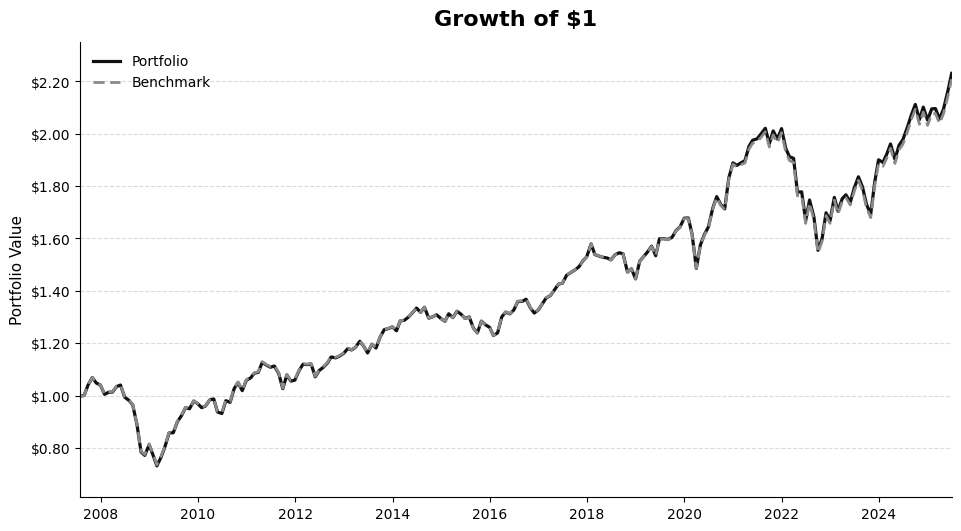

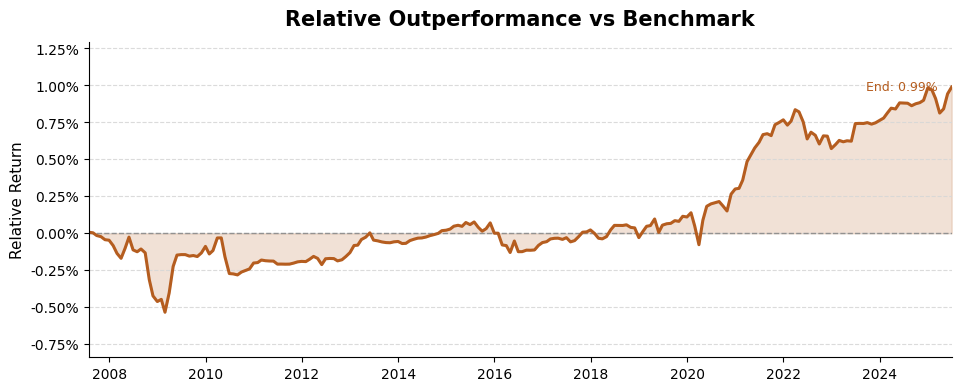

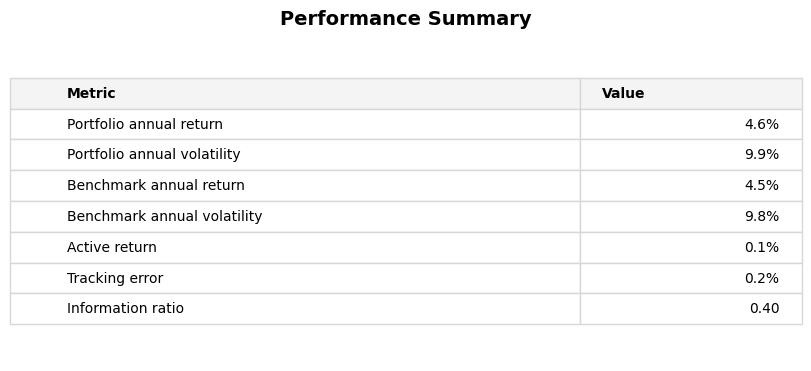

In [51]:
n_months = len(backtest_results)

portfolio_ann_return = (backtest_results['Portfolio Growth'].iloc[-1] ** (12 / n_months)) - 1
benchmark_ann_return = (backtest_results['Benchmark Growth'].iloc[-1] ** (12 / n_months)) - 1
portfolio_ann_vol = backtest_results['Portfolio Return'].std(ddof=1) * np.sqrt(12)
benchmark_ann_vol = backtest_results['Benchmark Return'].std(ddof=1) * np.sqrt(12)

active_ann_return = backtest_results['Active Return'].mean() * 12
tracking_error = backtest_results['Active Return'].std(ddof=1) * np.sqrt(12)
information_ratio = (
    np.nan if np.isclose(tracking_error, 0.0) else active_ann_return / tracking_error
)

plt.style.use('default')
series = backtest_results[['Date', 'Portfolio Growth', 'Benchmark Growth']].copy()
series['Relative Performance'] = (
    series['Portfolio Growth'] / series['Benchmark Growth'] - 1.0
)
portfolio_color = '#111111'
benchmark_color = '#8a8a8a'
relative_color = '#b55d1f'
grid_color = '#d7d7d7'

summary_rows = [
    ['Portfolio annual return', f'{portfolio_ann_return:.1%}'],
    ['Portfolio annual volatility', f'{portfolio_ann_vol:.1%}'],
    ['Benchmark annual return', f'{benchmark_ann_return:.1%}'],
    ['Benchmark annual volatility', f'{benchmark_ann_vol:.1%}'],
    ['Active return', f'{active_ann_return:.1%}'],
    ['Tracking error', f'{tracking_error:.1%}'],
    ['Information ratio', 'N/A' if pd.isna(information_ratio) else f'{information_ratio:.2f}'],
]
summary_df = pd.DataFrame(summary_rows, columns=['Metric', 'Value'])

growth_fig, growth_ax = plt.subplots(
    figsize=(9.5, 5.2),
    facecolor='white',
    constrained_layout=True,
)
growth_ax.plot(series['Date'], series['Portfolio Growth'], color=portfolio_color, linewidth=2.3, label='Portfolio')
growth_ax.plot(
    series['Date'],
    series['Benchmark Growth'],
    color=benchmark_color,
    linewidth=2.0,
    linestyle=(0, (4, 2)),
    label='Benchmark',
)
growth_ax.set_title('Growth of $1', fontsize=16, fontweight='bold', pad=12)
growth_ax.set_ylabel('Portfolio Value', fontsize=11)
growth_ax.yaxis.set_major_formatter(FuncFormatter(lambda y, _: f'${y:,.2f}'))
growth_ax.xaxis.set_major_locator(mdates.YearLocator(2))
growth_ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
growth_ax.set_xlim(series['Date'].iloc[0], series['Date'].iloc[-1])
growth_ax.grid(axis='y', color=grid_color, linestyle='--', linewidth=0.8, alpha=0.9)
growth_ax.grid(axis='x', alpha=0)
growth_ax.spines['top'].set_visible(False)
growth_ax.spines['right'].set_visible(False)
growth_ax.legend(loc='upper left', frameon=False, fontsize=10)
growth_ax.margins(x=0.01, y=0.08)
plt.show()

relative_range = series['Relative Performance'].max() - series['Relative Performance'].min()
relative_pad = max(relative_range, 0.002) * 0.20

relative_fig, relative_ax = plt.subplots(
    figsize=(9.5, 3.8),
    facecolor='white',
    constrained_layout=True,
)
relative_ax.axhline(0.0, color=benchmark_color, linewidth=1.0, linestyle='--', alpha=0.9)
relative_ax.fill_between(
    series['Date'],
    0.0,
    series['Relative Performance'],
    color=relative_color,
    alpha=0.18,
)
relative_ax.plot(
    series['Date'],
    series['Relative Performance'],
    color=relative_color,
    linewidth=2.2,
)
relative_ax.set_title('Relative Outperformance vs Benchmark', fontsize=15, fontweight='bold', pad=12)
relative_ax.set_ylabel('Relative Return', fontsize=11)
relative_ax.yaxis.set_major_formatter(FuncFormatter(lambda y, _: f'{y:.2%}'))
relative_ax.xaxis.set_major_locator(mdates.YearLocator(2))
relative_ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
relative_ax.set_xlim(series['Date'].iloc[0], series['Date'].iloc[-1])
relative_ax.set_ylim(
    series['Relative Performance'].min() - relative_pad,
    series['Relative Performance'].max() + relative_pad,
)
relative_ax.grid(axis='y', color=grid_color, linestyle='--', linewidth=0.8, alpha=0.9)
relative_ax.grid(axis='x', alpha=0)
relative_ax.spines['top'].set_visible(False)
relative_ax.spines['right'].set_visible(False)
relative_ax.annotate(
    f"End: {series['Relative Performance'].iloc[-1]:.2%}",
    xy=(series['Date'].iloc[-1], series['Relative Performance'].iloc[-1]),
    xytext=(-10, 0),
    textcoords='offset points',
    ha='right',
    va='center',
    fontsize=9,
    color=relative_color,
)
plt.show()

table_fig, table_ax = plt.subplots(
    figsize=(8.0, 3.6),
    facecolor='white',
    constrained_layout=True,
)
table_ax.axis('off')
table_ax.set_title('Performance Summary', fontsize=14, fontweight='bold', pad=12)
table = table_ax.table(
    cellText=summary_rows,
    colLabels=['Metric', 'Value'],
    cellLoc='left',
    colLoc='left',
    loc='center',
    colWidths=[0.72, 0.28],
)
table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1, 1.6)

for (row, col), cell in table.get_celld().items():
    cell.set_edgecolor(grid_color)
    if row == 0:
        cell.set_facecolor('#f4f4f4')
        cell.get_text().set_fontweight('bold')
    elif col == 1:
        cell.get_text().set_ha('right')

plt.show()




In [52]:
SAVE_RESULTS = True
RESULT_NAME = "bond_em"  # Required when SAVE_RESULTS=True. This becomes result/<RESULT_NAME>/.

saved_paths_df = save_experiment_outputs(
    enabled=SAVE_RESULTS,
    run_name=RESULT_NAME,
    backtest_results=backtest_results,
    optimal_weights=optimal_weights,
    optimization_diagnostics=optimization_diagnostics,
    holding_period_summary=holding_period_summary,
    adaptive_view_summary=adaptive_view_summary,
    q_table=Q_table,
    omega_multiplier_table=Omega_multiplier_table,
    summary_df=summary_df,
    growth_fig=growth_fig,
    relative_fig=relative_fig,
    table_fig=table_fig,
)

if saved_paths_df is not None:
    display(saved_paths_df)

,Group,Artifact,Path
0,bl,adaptive_view_summary,D:\python_learning_virtual_evns\MATH5380\long_...
1,bl,q_table,D:\python_learning_virtual_evns\MATH5380\long_...
2,bl,omega_multiplier_table,D:\python_learning_virtual_evns\MATH5380\long_...
3,bl,optimal_weights,D:\python_learning_virtual_evns\MATH5380\long_...
4,bl,optimization_diagnostics,D:\python_learning_virtual_evns\MATH5380\long_...
5,backtest,backtest_results,D:\python_learning_virtual_evns\MATH5380\long_...
6,backtest,holding_period_summary,D:\python_learning_virtual_evns\MATH5380\long_...
7,summary,performance_summary,D:\python_learning_virtual_evns\MATH5380\long_...
8,figures,growth_chart,D:\python_learning_virtual_evns\MATH5380\long_...
9,figures,relative_outperformance_chart,D:\python_learning_virtual_evns\MATH5380\long_...
